# Etude 2 : exploration des espaces latents SPINVAE-2

Troisieme notebook de l'investigation, apres `imgep_investigation.ipynb` (diversite dans
l'espace de comportement Z) et `theta_investigation.ipynb` (diagnostic dans l'espace des
parametres Theta). Celui-ci change de substrat : au lieu d'explorer les 155 parametres bruts
de Dexed, on explore le **vecteur latent 256-D de SPINVAE-2**, le decodeur se chargeant de
produire le preset. Toute la machinerie en aval (rendu audio, 38 descripteurs perceptifs,
metriques) est **identique** a l'etude 1 -- c'est la condition pour que les deux etudes
soient comparables.

**Les 4 variantes** sont l'ablation 2x2 des deux termes de regularisation latente, entrainees
depuis zero pendant le stage :

| variante | KL (beta) | timbre (gamma) |
|---|---|---|
| `avec_tout` | 5e-5 | 1e-3 |
| `sans_timbre` | 5e-5 | 0 |
| `sans_KL` | 0 | 1e-3 |
| `sans_les_deux` | 0 | 0 |

**Les hypotheses testees**, heritees des conclusions de l'etude 1 :

- **H3 (attracteurs degeneres)** : un espace appris et regularise devrait concentrer les
  comportements atteignables loin des regions degenerees, donc supprimer l'attracteur de
  silence qui gaspillait la moitie du budget en parametrique.
- **H1/H2 (redondance et calibration du mutateur)** : la mutation devient un simple bruit
  gaussien isotrope dans z, a la place de la routine type-aware a 155 parametres dont
  l'etude 1 avait identifie la miscalibration comme facteur central. Un espace continu et
  lisse devrait donc etre plus facile a explorer.

**Reponses courtes** : (1) H3 est confirmee sans ambiguite -- 0 % de silence sur 3 variantes
sur 4 ; (2) et pourtant la diversite s'effondre quand meme, d'un facteur 4 a 5 sous le
parametrique ; (3) mais le pas de mutation n'a jamais ete calibre, et le diagnostic de
localite montre qu'il est ~3x trop petit -- donc l'effondrement observe n'est pas encore
attribuable a l'espace latent lui-meme.

**Plan**
1. Setup et chargement
2. Le silence : H3 confirmee
3. Diversite face aux references parametriques
4. Evolution cumulative : la signature d'effondrement
5. Projection UMAP de l'espace de comportement
6. La reserve : sigma n'est pas calibre
7. Conclusion et suite

## 1. Setup

Les runs : 500 iterations par variante, `bootstrap_size=100`, graine 0 identique pour les
quatre -- seul l'espace latent change. `sigma=0.1` (valeur par defaut du template, cf.
section 6). Explorer IMGEP standard, **pas** le niche-biased de l'etude 1 : on veut d'abord
observer la boucle nue en coordonnees latentes.

Les figures sont produites par `scripts/latent_figures.py` (memes conventions de z-score, de
grille PCA-4D et de Vendi que partout ailleurs dans le projet).

In [2]:
import os, sys, pathlib, json
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

import numpy as np
from sklearn.decomposition import PCA
from IPython.display import Image, display

DEXED_ROOT = pathlib.Path.home() / 'projects' / 'spinvae2' / 'adtool' / 'dexed'
os.chdir(DEXED_ROOT)
sys.path.insert(0, str(DEXED_ROOT))
sys.path.insert(0, str(pathlib.Path.home() / 'projects' / 'spinvae2'))

from coverage_diversity import vendi_score

N_BOOT = 100
VARIANTS = ['avec_tout', 'sans_timbre', 'sans_KL', 'sans_les_deux']


def load_z(d, cap=None):
    files = sorted(pathlib.Path(d).rglob('discovery.json'))
    if cap is not None:
        files = files[:cap]
    return np.asarray([json.load(f.open())['output'] for f in files], dtype=float)


def drop_nan(M):
    return M[~np.isnan(M).any(axis=1)]


def silence_rate(M):
    """Part de decouvertes quasi-silencieuses : Z tout-a-zero, le fallback de
    DexedStatistics quand le rendu a une crete < 1e-4."""
    return 100.0 * (np.abs(M).max(axis=1) < 1e-9).mean()


sets = {v: drop_nan(load_z(f'runs/latent/{v}')) for v in VARIANTS}
sets['full (param)'] = drop_nan(load_z('runs/confirm/full/seed0', cap=500))
random_pool = drop_nan(load_z('runs/random/combined/discoveries'))
sets['random (param)'] = random_pool[:500]
ORDER = VARIANTS + ['full (param)', 'random (param)']
for k in ORDER:
    print(f'{k:16s} {len(sets[k])}')

avec_tout        500
sans_timbre      500
sans_KL          500
sans_les_deux    500
full (param)     500
random (param)   500


In [3]:
# Geometrie partagee : z-score et grille PCA-4D communes a tous les jeux compares
ref = np.concatenate([sets[k] for k in ORDER] + [random_pool])
mu, sd = ref.mean(axis=0), ref.std(axis=0)
sd[sd == 0] = 1.0
zs = lambda M: (M - mu) / sd

pca = PCA(n_components=4, random_state=0).fit(zs(ref))
pp = pca.transform(zs(ref))
lo, hi = np.percentile(pp, 0.5, axis=0), np.percentile(pp, 99.5, axis=0)
edges = [np.linspace(lo[d], hi[d], 9) for d in range(4)]

def cells_occupied(M):
    P = np.clip(pca.transform(zs(M)), lo, hi)
    idx = np.stack([np.clip(np.digitize(P[:, d], edges[d][1:-1]), 0, 7) for d in range(4)], axis=1)
    return len({tuple(r) for r in idx})

print(f'{"jeu":16s} {"sil.boot":>9s} {"sil.guide":>10s} {"Vendi":>7s} {"couverture":>11s}')
for k in ORDER:
    M = sets[k]
    print(f'{k:16s} {silence_rate(M[:N_BOOT]):8.1f}% {silence_rate(M[N_BOOT:]):9.1f}% '
          f'{vendi_score(zs(M)):7.2f} {cells_occupied(M):11d}')

jeu               sil.boot  sil.guide   Vendi  couverture
avec_tout             0.0%       0.0%    3.84          52
sans_timbre           0.0%       0.0%    3.21          44
sans_KL               4.0%      84.2%    3.84          74
sans_les_deux         0.0%       0.0%    3.82          41
full (param)          6.0%       7.8%   17.44         214
random (param)       11.0%       8.5%   15.72          55


## 2. Le silence : H3 confirmee

C'etait la prediction la plus nette de l'etude 1 : l'attracteur de silence est un artefact du
banc d'essai parametrique (une grande partie de l'espace des 155 parametres bruts rend du
silence), pas une propriete de l'exploration par curiosite. Un espace latent appris sur des
presets reels ne devrait pas avoir cette region.

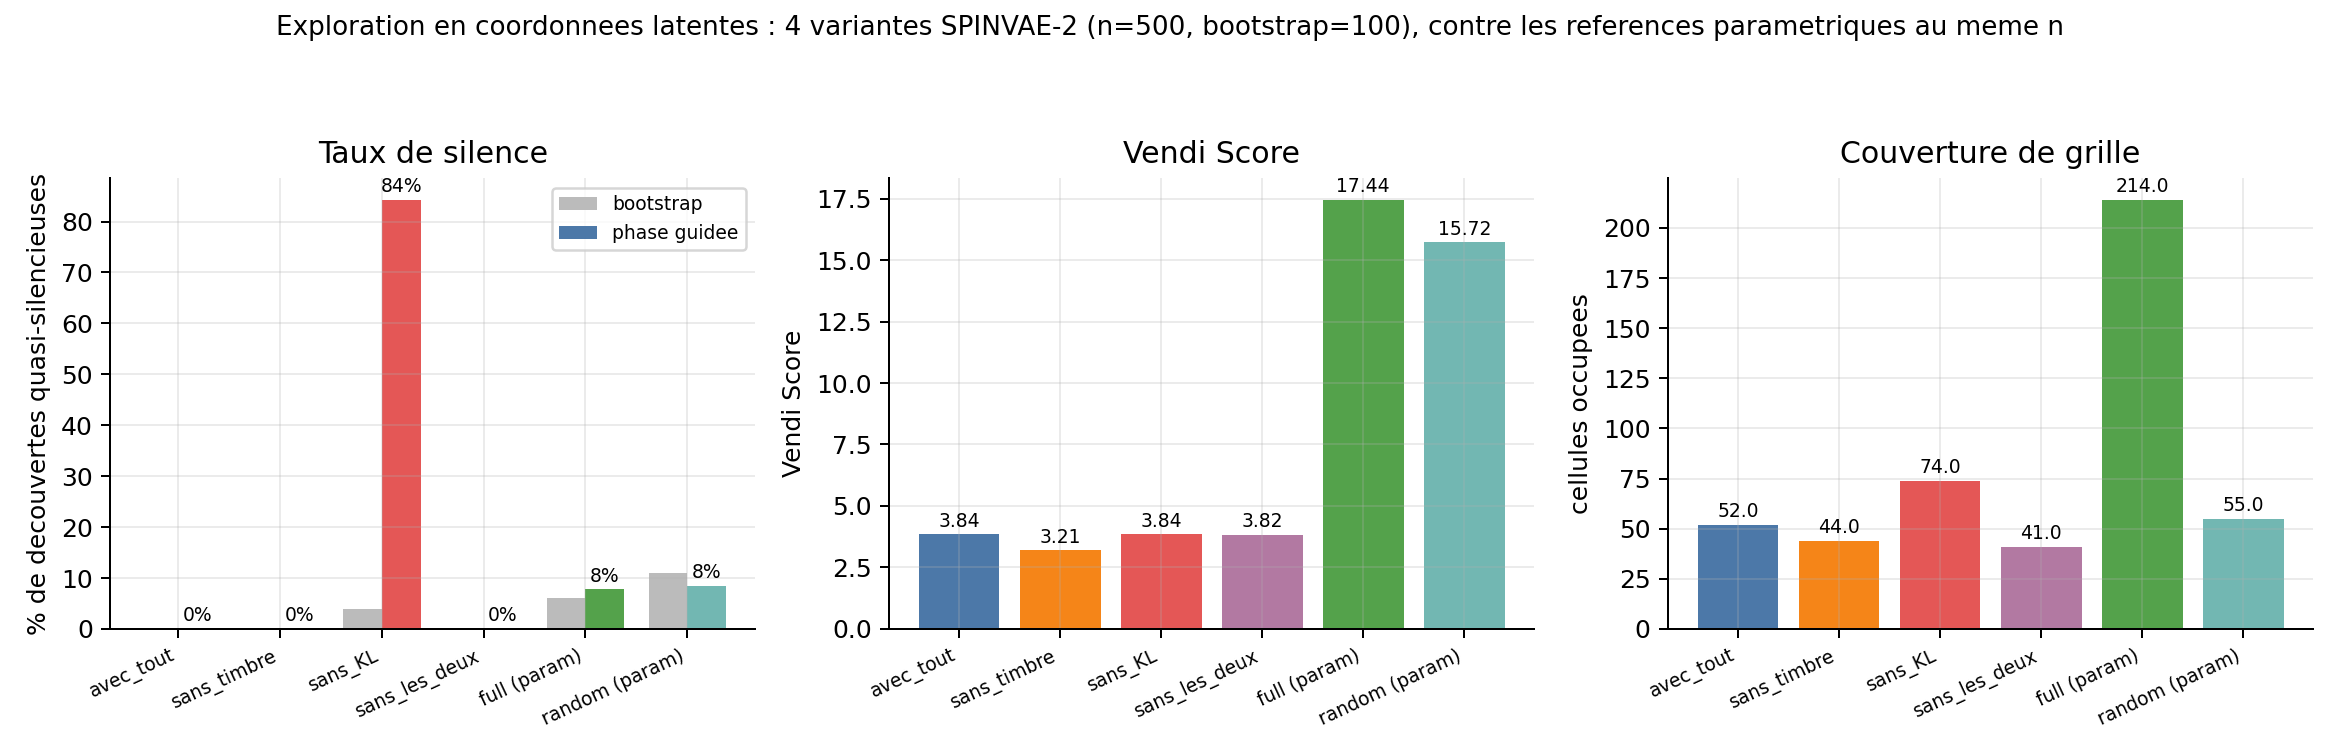

In [4]:
display(Image('figures/latent_overview.png'))

### Resultat : 0 % de silence sur 3 variantes sur 4

| variante | silence bootstrap | silence phase guidee |
|---|---|---|
| `avec_tout` | 0,0 % | **0,0 %** |
| `sans_timbre` | 0,0 % | **0,0 %** |
| `sans_les_deux` | 0,0 % | **0,0 %** |
| `sans_KL` | 4,0 % | **84,2 %** |
| *full (param)* | *6,0 %* | *7,6 %* |
| *random (param)* | *11,0 %* | *8,0 %* |

**H3 est confirmee sans ambiguite.** Zero decouverte silencieuse sur 500, dans les deux
phases, pour trois variantes sur quatre. Le mecanisme qui gaspillait plus de la moitie du
budget en parametrique (53,9 % pour la baseline de l'etude 1) disparait purement et
simplement quand on explore un espace appris sur des presets humains. C'est aussi une
validation indirecte du diagnostic de regression des porteuses : le decodeur ne produit pas
de presets aux porteuses effondrees, parce qu'il n'en a jamais vu.

**`sans_KL` est le contre-exemple instructif**, et il est coherent avec la theorie. C'est la
seule variante entrainee **sans terme KL**, donc la seule dont l'espace latent n'est pas
contraint a ressembler a une distribution reguliere. Des que la mutation s'eloigne des
encodages du corpus, elle sort de la variete apprise et le decodeur produit du silence : 4 %
pendant le bootstrap (qui echantillonne la banque empirique, donc reste sur la variete),
**84 % des que la mutation guidee prend le relais**. Le role du terme KL -- garantir que les
points *entre* les encodages decodent encore en quelque chose de valide -- se lit directement
dans ce chiffre.

Autrement dit : la propriete de **validite** listee en section SOTA du rapport (les points
decodes doivent rester dans la region des sons plausibles) n'est pas acquise par construction,
elle est achetee par la regularisation KL.

## 3. Diversite face aux references parametriques

Le silence regle, reste la question centrale : est-ce que l'espace latent est *mieux
explorable* ? Comparaison au **meme n=500**, les deux mesures etant sensibles a la taille
d'echantillon.

| jeu | Vendi | couverture |
|---|---|---|
| `avec_tout` | 3,84 | 52 |
| `sans_timbre` | 3,21 | 44 |
| `sans_KL` | 3,84 | 74 |
| `sans_les_deux` | 3,82 | 41 |
| **full (param)** | **17,44** | **214** |
| **random (param)** | **15,72** | **55** |

**Non.** Un facteur 4 a 5 sous le parametrique sur le Vendi Score, et sous le random lui-meme
sur la couverture pour trois variantes. C'est un ecart bien plus grand que tout ce qui separe
les variantes entre elles -- l'effet « quel espace latent » est negligeable devant l'effet
« latent vs parametrique ».

A noter : `sans_KL` a la meilleure couverture des quatre (74) **malgre** ses 84 % de silence.
Ses 16 % de decouvertes sonores tombent tres loin les unes des autres -- c'est la signature
d'une exploration qui sort de la variete et decode du bruit, pas d'une exploration reussie.
Un bon rappel que la couverture brute ne dit rien de la qualite musicale, la reserve deja
formulee en discussion de l'etude 1.

## 4. Evolution cumulative : la signature d'effondrement

La comparaison des valeurs finales ne dit pas *quand* l'ecart se creuse. On refait donc le
diagnostic qui avait ete decisif dans l'etude 1 : suivre les deux mesures en cumulatif, en
marquant la bascule bootstrap -> mutation guidee.

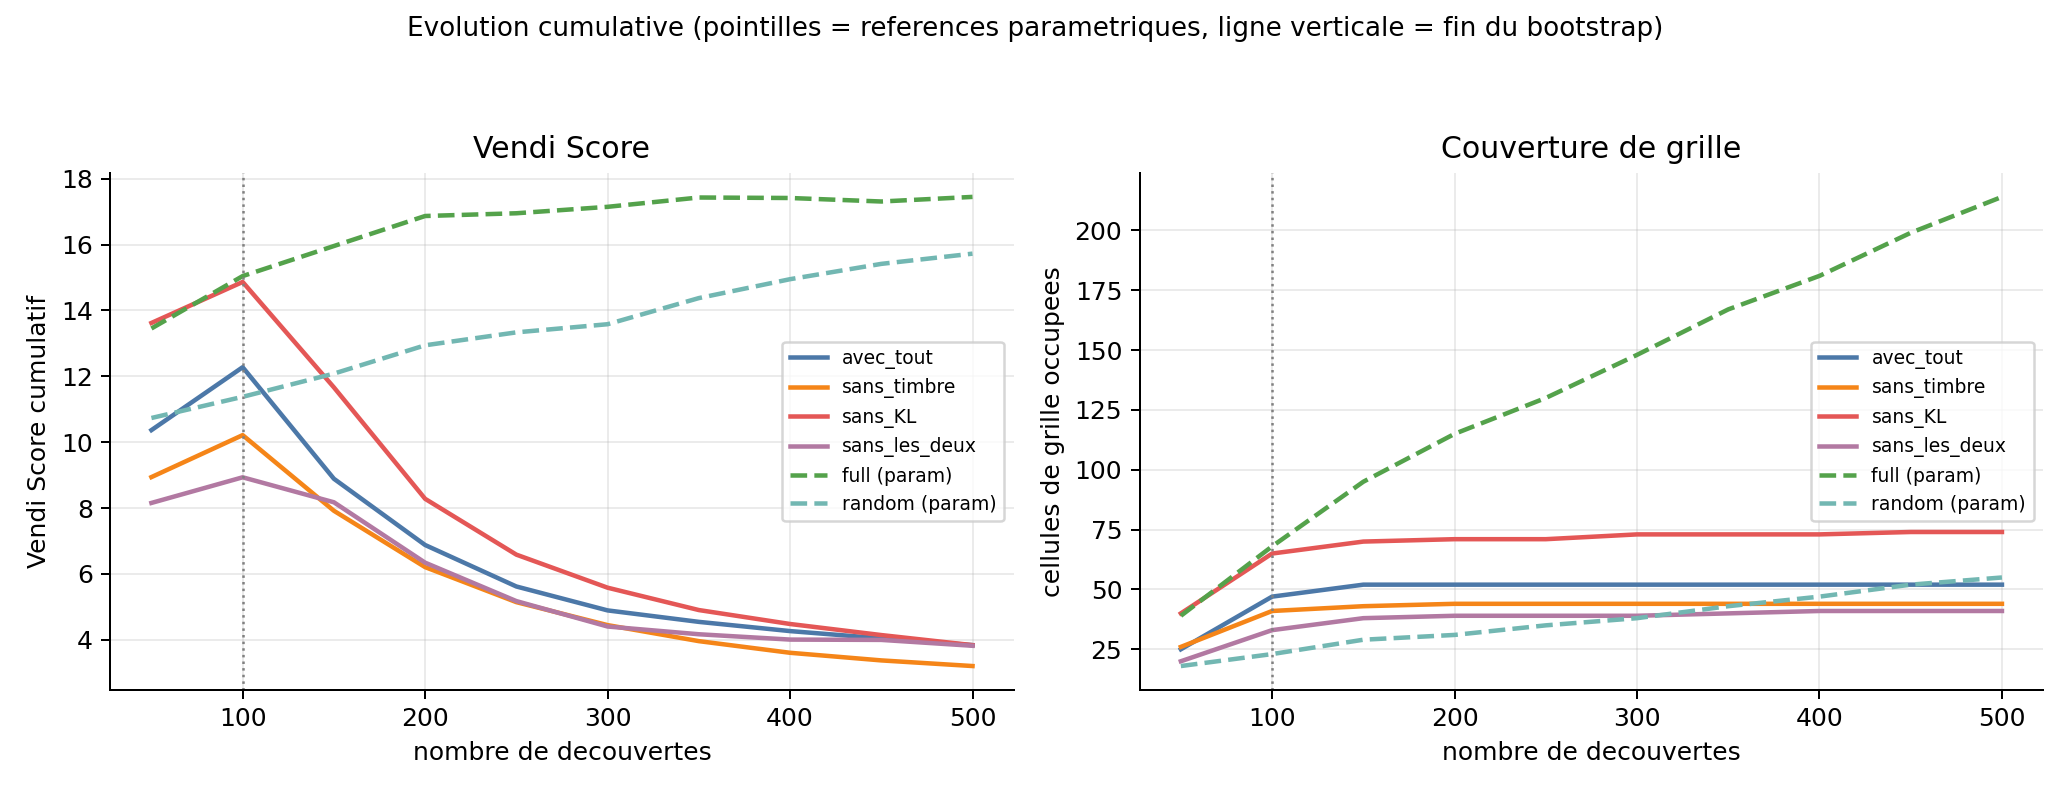

In [5]:
display(Image('figures/latent_evolution.png'))

### Resultat : le meme effondrement a la bascule, sans le silence

Les quatre courbes latentes montent normalement pendant le bootstrap (elles echantillonnent
la banque empirique, donc c'est de l'aleatoire), atteignent leur maximum **exactement a
n=100**, puis s'effondrent des que la mutation guidee demarre :

| variante | Vendi a n=100 | a n=200 | a n=300 | a n=500 |
|---|---|---|---|---|
| `avec_tout` | 12,3 | 6,9 | 4,9 | 3,8 |
| `sans_timbre` | 10,2 | 6,2 | 4,5 | 3,2 |
| `sans_KL` | 15,0 | 8,3 | 5,6 | 3,8 |
| `sans_les_deux` | 8,9 | 6,4 | 4,5 | 3,8 |

Cote couverture c'est encore plus net : les quatre variantes **plafonnent completement des
~150 iterations** et n'ouvrent plus une seule cellule nouvelle pendant les 350 iterations
suivantes, pendant que le parametrique continue de grimper lineairement.

**C'est le resultat le plus important de ce notebook**, parce qu'il dissocie deux mecanismes
que l'etude 1 ne pouvait pas separer. En parametrique, l'effondrement et l'attracteur de
silence arrivaient ensemble, et il etait tentant de lire le premier comme une consequence du
second. Ici le silence est **totalement absent** (0 % pour `avec_tout`, `sans_timbre`,
`sans_les_deux`) et l'effondrement se produit exactement pareil, a la meme iteration, avec la
meme forme de courbe.

Le silence n'etait donc pas la cause de l'effondrement -- seulement un aggravateur propre au
banc d'essai parametrique. La cause est ailleurs : dans la boucle
plus-proche-voisin + mutation locale elle-meme (H2), independamment du substrat.

## 5. Projection UMAP de l'espace de comportement

Les metriques agregees disent *combien* de diversite ; la projection dit *ou*. Une UMAP
conjointe est ajustee sur l'union de tous les jeux (les 4 variantes, les 2 references
parametriques et un echantillon du corpus humain), puis chaque jeu est affiche sur le meme
plan.

Attention a ce qui est comparable : les quatre variantes ont des espaces latents **256-D
differents et non commensurables** entre eux (ni avec les 155-D de Theta). Toute comparaison
inter-methodes doit donc se faire dans l'espace de comportement Z partage -- c'est
precisement pourquoi il est tenu fixe entre les deux etudes.

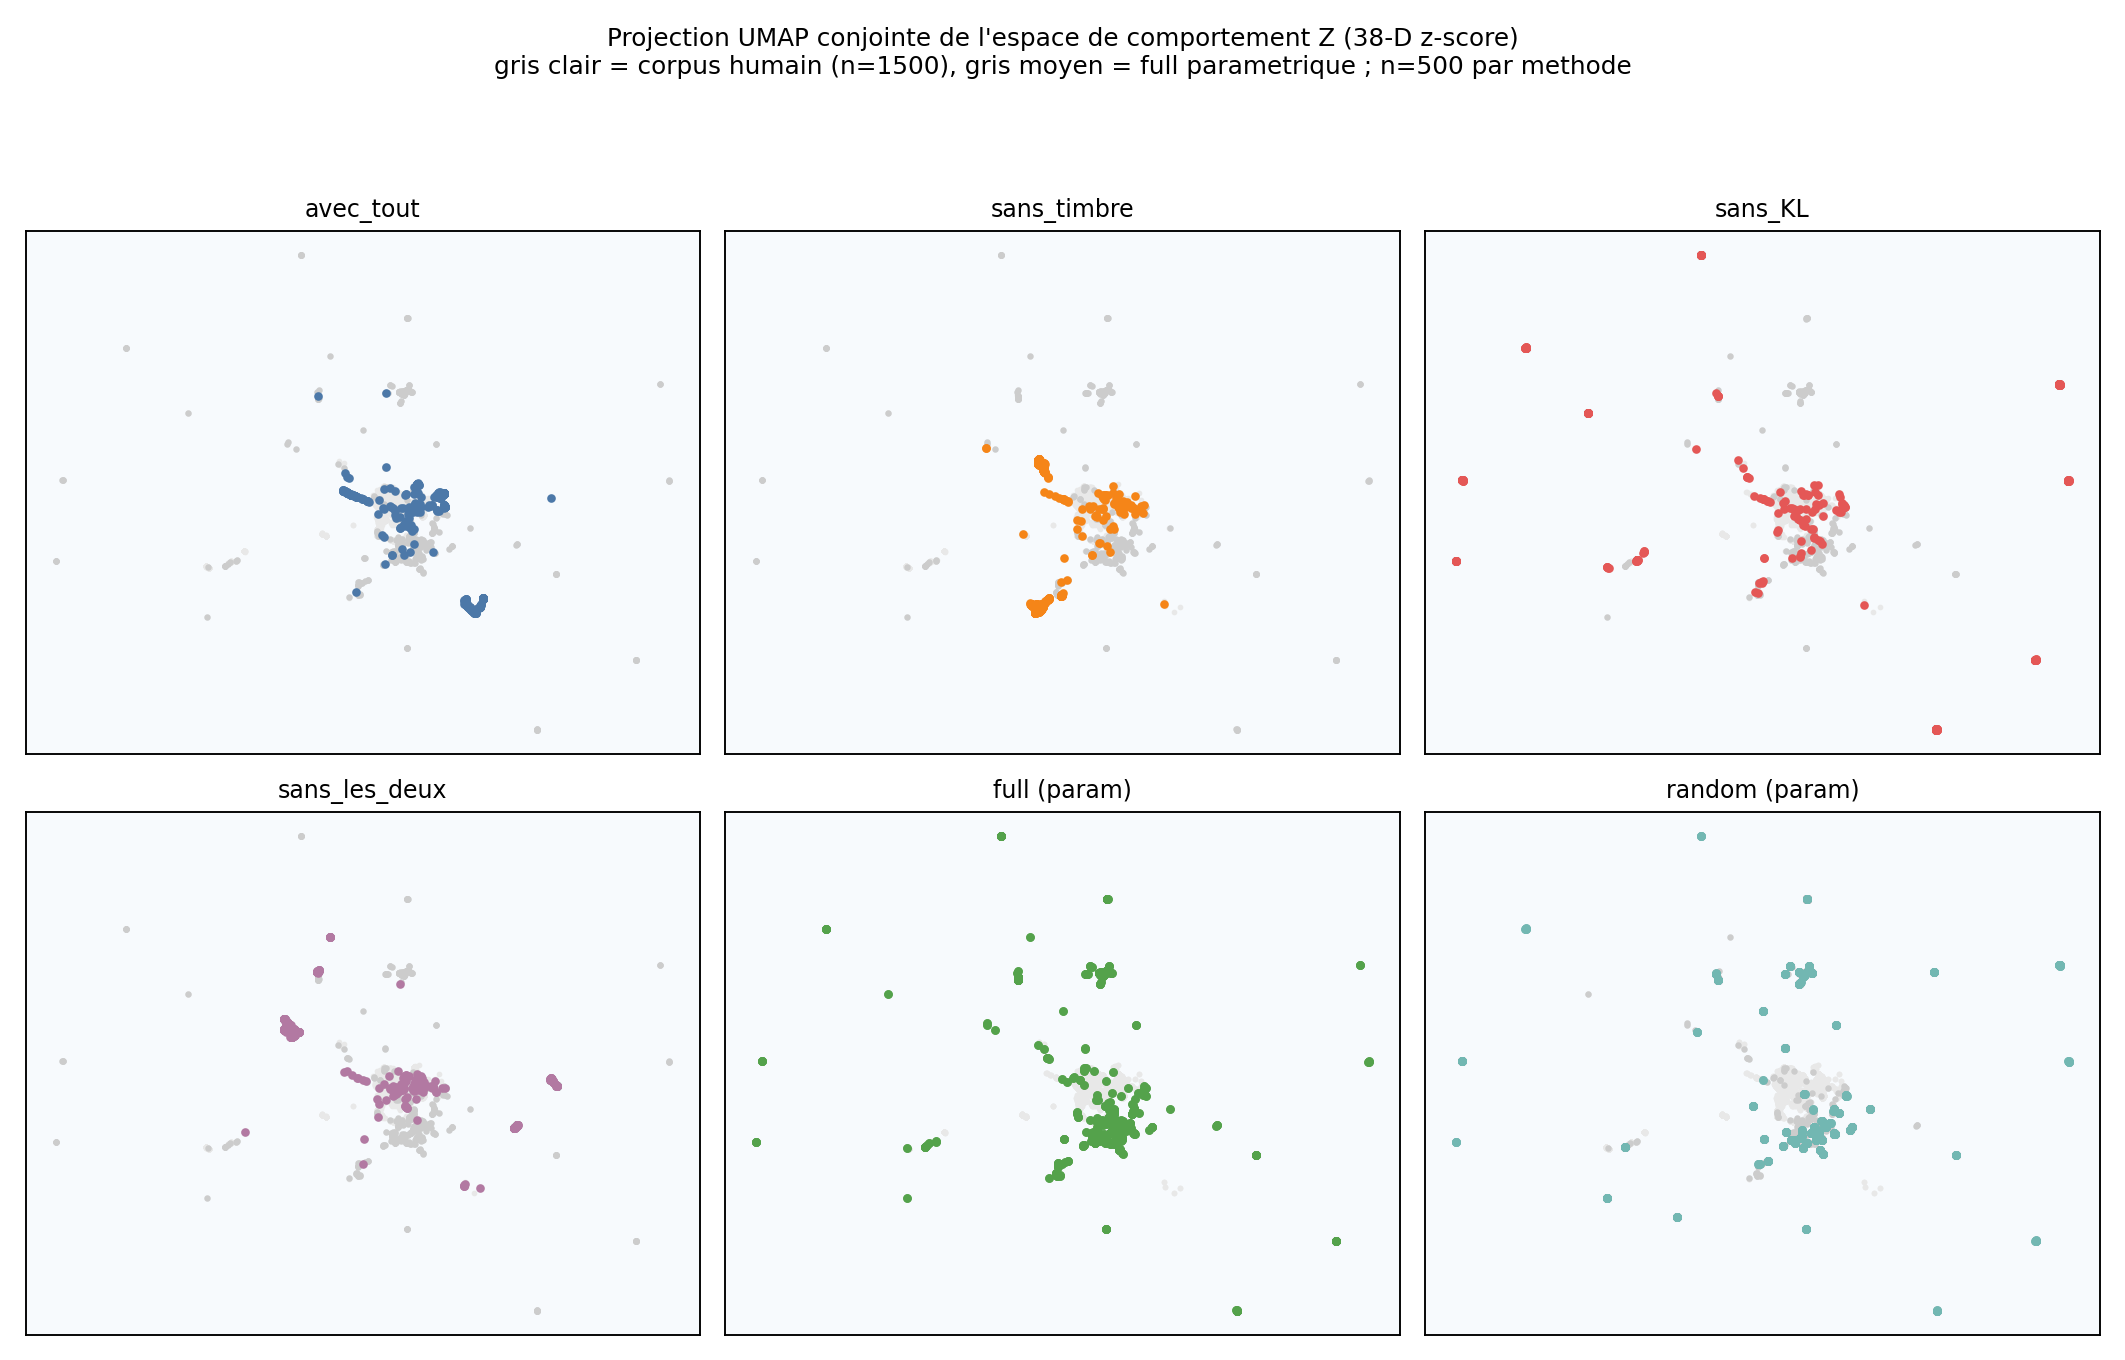

In [6]:
display(Image('figures/latent_projection.png'))

### Resultat : les variantes latentes restent au centre du nuage humain

Les quatre variantes occupent un noyau compact, largement superpose au corpus humain (gris
clair) et au coeur du nuage parametrique (gris moyen). Le parametrique `full` et le `random`,
eux, essaiment de nombreux points loin du centre, dans des regions que le corpus humain
n'occupe pas.

Deux lectures, non exclusives, et c'est exactement la tension du sujet :

- **Lecture pessimiste** : les runs latents n'explorent qu'une petite poche. Ils ne
  decouvrent rien qui sorte de ce que les humains font deja -- ce qui est l'inverse de
  l'objectif d'un outil de decouverte.
- **Lecture optimiste** : ce que les runs latents produisent est, par construction, dans la
  region des sons plausibles. Les points lointains du parametrique sont « divers » au sens
  des descripteurs, mais l'etude 1 a etabli qu'une bonne partie d'entre eux sont des sons
  degeneres -- loin les uns des autres dans l'espace des descripteurs sans etre
  musicalement interessants.

`sans_KL` se distingue visuellement : c'est la seule a projeter des points tres a l'ecart,
isoles. Ce sont ses decouvertes hors-variete -- cohérent avec ses 84 % de silence et sa
couverture artificiellement haute.

## 6. La reserve : sigma n'est jamais calibre

Avant de conclure quoi que ce soit sur l'espace latent, il faut regarder le pas de mutation.
Le template de config le signale explicitement (« calibrate against study 1's mutation
locality before the main runs ») : `sigma=0.1` signifie « un pas de mutation = 10 % de
l'ecart-type empirique par dimension latente », une valeur choisie par defaut, jamais reglee.

Le diagnostic de localite de l'etude 1 se transpose directement : on mesure le deplacement
moyen entre decouvertes consecutives **dans Z**, pendant le bootstrap puis pendant la phase
guidee. Un rapport proche de 1 signifie que la mutation deplace autant qu'un tirage
independant ; un rapport eleve signifie que la recherche est trop locale.

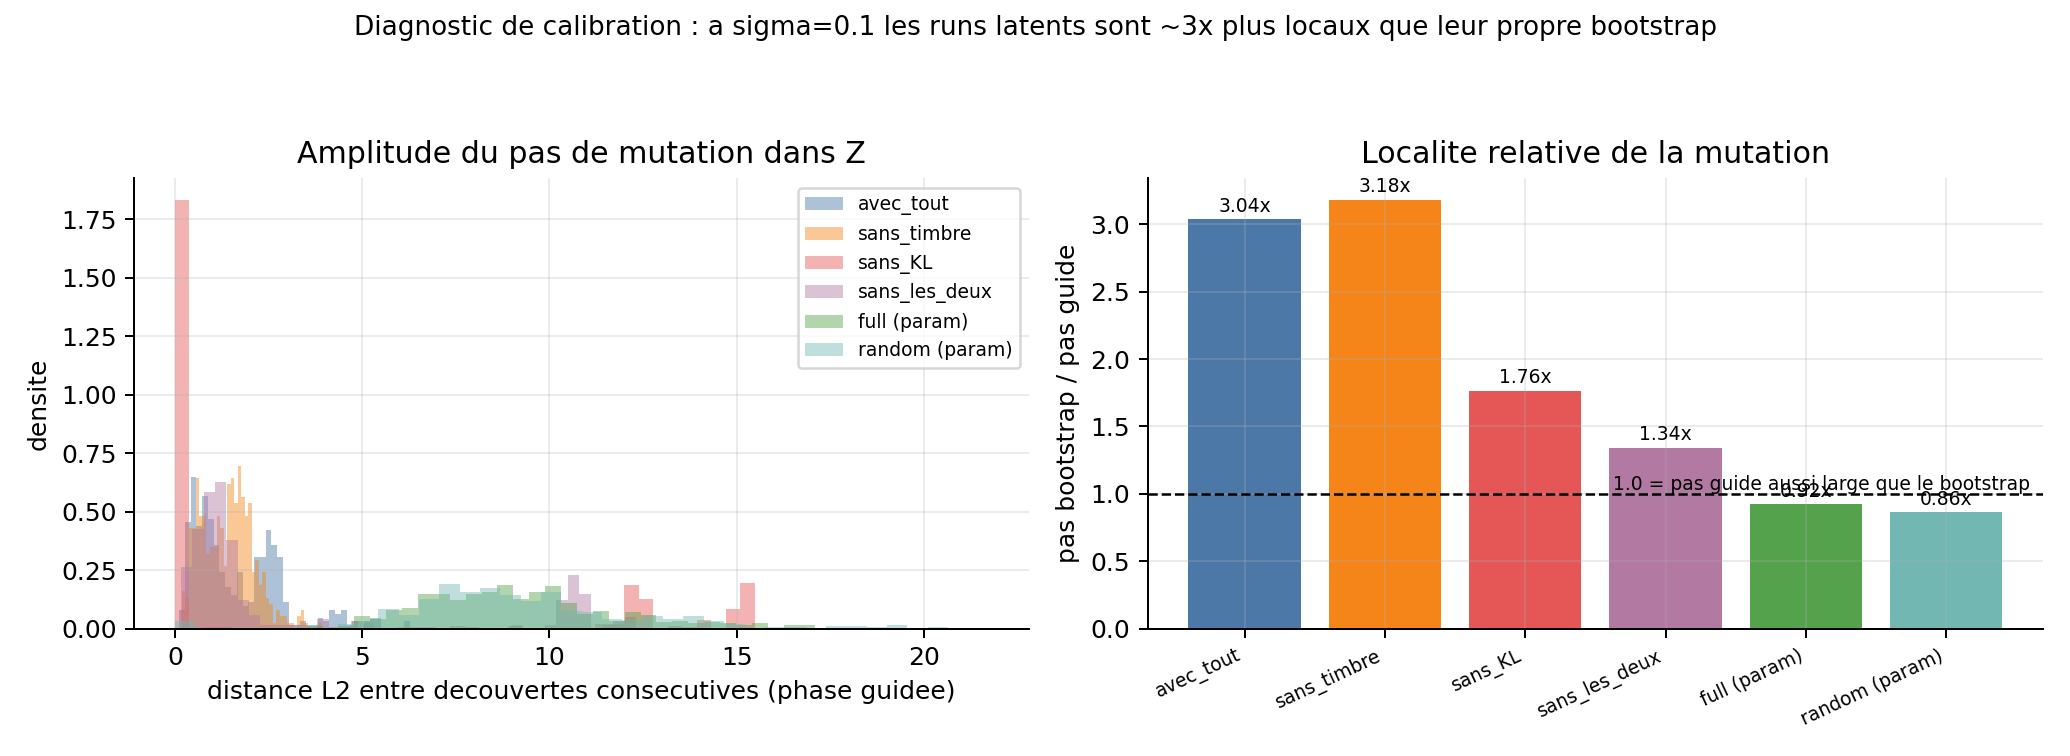

In [7]:
display(Image('figures/latent_locality.png'))

### Resultat : les runs latents sont ~3x trop locaux

| jeu | pas bootstrap | pas guide | rapport |
|---|---|---|---|
| `avec_tout` | 6,57 | 1,89 | **3,47x** |
| `sans_timbre` | 5,68 | 1,78 | **3,19x** |
| `sans_KL` | 8,04 | 3,82 | 2,10x |
| `sans_les_deux` | 4,99 | 3,28 | 1,52x |
| **full (param)** | 10,77 | 11,95 | **0,90x** |

`full` en parametrique est a **0,90x** : sa mutation guidee deplace autant qu'un tirage
aleatoire independant -- c'est precisement ce que les correctifs de l'etude 1 ont obtenu.
Les runs latents sont a **3,2-3,5x**, c'est-a-dire exactement le regime que l'etude 1 avait
identifie comme pathologique (3,75x pour la baseline parametrique non corrigee, avant tout
correctif).

**Conclusion methodologique** : l'effondrement documente en section 4 est tres probablement
un artefact de `sigma` trop petit, et non une propriete de l'espace latent. Conclure
« l'espace latent s'explore mal » a partir de ces runs serait commettre exactement l'erreur
que l'etude 1 a mis des semaines a corriger -- attribuer a l'espace ce qui appartient au
mutateur.

L'analogie est d'ailleurs precise : en parametrique, le sweep `noise_scale` (x0,5 a x4)
n'avait rien change parce que le probleme n'etait pas l'amplitude globale mais un biais
structurel (la regression des porteuses). Ici, rien ne dit encore si augmenter `sigma`
suffira ou si un biais analogue existe en latent. C'est une question ouverte, pas une
conclusion.

## 7. Conclusion et suite

**1. H3 est confirmee, proprement.** 0 % de silence sur 3 variantes sur 4, contre 53,9 % pour
la baseline parametrique de l'etude 1. L'attracteur de silence etait bien un artefact du banc
d'essai parametrique, pas une fatalite de l'exploration par curiosite.

**2. Le terme KL achete la validite.** `sans_KL` est la seule variante a produire du silence,
et massivement (84 % en phase guidee contre 4 % en bootstrap). Sans contrainte sur la forme
de la distribution latente, la mutation sort de la variete apprise et le decodeur produit du
dechet. C'est une mesure directe, et a notre connaissance inedite, de ce que la
regularisation KL apporte a l'**explorabilite** -- et non seulement a la qualite de
reconstruction, ou les quatre variantes sont indistinguables (MSE 0,0093-0,0111).

**3. L'effondrement survit au changement de substrat, et c'est le resultat structurant.**
Meme forme de courbe, meme iteration de bascule, sans le moindre silence pour l'expliquer.
Le silence n'etait pas la cause : la boucle plus-proche-voisin + mutation locale l'est.

**4. Mais rien n'est concluant tant que sigma n'est pas calibre.** Les runs sont 3x plus
locaux que leur propre bootstrap, dans le regime que l'etude 1 avait identifie comme
pathologique. Ce notebook documente un premier passage exploratoire, pas un resultat.

### Prochaine etape

Balayage de `sigma` (0,3 / 0,5 / 1,0) sur `avec_tout` seule, ~300 iterations chacune, avec
pour critere d'arret le **rapport de localite ramene vers 1,0** -- le meme critere qui a
guide la correction du mutateur parametrique. Ce n'est qu'ensuite que relancer les 4
variantes a budget plus large aura du sens.

Deux points d'infrastructure a retenir, corriges pour permettre ces runs (l'integration
latente n'avait jamais tourne) :
- les checkpoints stage-2 doivent vivre sous `~/projects/spinvae2/checkpoints_shared/`
  (NFS partage) et non sous `/data` ou `/data2`, qui sont **locaux a chaque machine** :
  un entrainement fait sur gottan est invisible depuis bonsho ;
- les `config.pickle` sauvegardes a l'entrainement figent les chemins de la machine
  d'entrainement ; `DexedLatentMap._load_model()` les reecrit desormais d'apres l'hote
  courant.